# Checkpoint 2: RQ Formation

## 1. Project Scope

- Dataset: Online Retail
- Course techniques: Frequent itemset mining and association rule mining
- External techniques: Sequential pattern mining
- EDA Findings:
  1. Item frequency is highly uneven: most products appear in only a small share of invoices, while a small number of popular products appear much more oftern.
  2. Item co-occurrence is also uneven: many item pairs occur only a few times, while a small set of strong pairs accounts for a large share of all co-occurrence events.
  3. Transaction gaps vary a lot across customers: many repeat purchases happen within a few weeks, but some customers return only after much longer gaps.

  These findings suggests that both support threshold choice and time order will matter in later analysis.

## 2. Research Question Definition

### RQ1. Do popular items hide more specific but useful basket patterns?

The original EDA showed that a small group of very common items appears in many invoices and drives many of the strongest co-occurrence pairs. This raises the question of whether these popular items dominate the results so much so that they hide smaller but more meaningful basket patterns.
- Data mining task type: Frequent itemset mining and association rule mining
- Relevant algorithms: Apriori or FP-Growth, followed by association rule generation
- Evaluation criteria: Support, confidence, lift, number of rules, and interpretability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def rq1_item_dominance_eda(
    file_path: str,
    top_n_items_table: int = 20,
    top_k_list=(10, 20, 50, 100),
    remove_top_k_list=(5, 10),
    top_m_items_for_pairs: int = 1000,
    max_basket_for_pairs: int = 200,
):
    """
    Perform additional EDA for RQ1:
    "Do popular items hide more specific but useful basket patterns?"

    What this function does
    - Loads the Online Retail dataset from an Excel file
    - Filters to purchase-only rows
    - Defines baskets as unique items per invoice
    - Computes top items by invoice-level support
    - Measures how much basket activity is concentrated in the most popular items
    - Measures how strongly top items dominate strong co-occurring pairs
    - Tests how basket structure changes after removing a few top items

    Parameters
    ----------
    file_path : str
        Path to the Online Retail Excel file.
    top_n_items_table : int, default=20
        Number of top items to return in the top-items table.
    top_k_list : tuple, default=(10, 20, 50, 100)
        Cutoffs used for head concentration summaries.
    remove_top_k_list : tuple, default=(5, 10)
        Numbers of top items to remove when testing basket sensitivity.
    top_m_items_for_pairs : int, default=1000
        Restrict co-occurrence analysis to the top-M most frequent items.
    max_basket_for_pairs : int, default=200
        Ignore invoices with more than this many unique items when generating item pairs.

    Returns
    -------
    dict
        Dictionary with:
        - df_purchase: cleaned purchase-only dataframe
        - invoice_item: deduplicated invoice-item table
        - item_support: support table for items
        - top_items: top items table
        - head_concentration: summary table for top-k item dominance
        - cumulative_item_curve: data for cumulative concentration plot
        - pair_anchor_summary: summary of how much top items dominate strong pairs
        - basket_sensitivity: summary after removing top items
        - pair_support_sorted: pair support table for optional inspection
    """
    # -----------------------------
    # 1) Load and clean
    # -----------------------------
    df = pd.read_excel(file_path)

    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str)

    is_cancellation = df["InvoiceNo"].str.startswith("C", na=False)

    df_purchase = df.loc[~is_cancellation].copy()
    df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
    df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()
    df_purchase = df_purchase.dropna(subset=["InvoiceNo", "StockCode"])
    df_purchase = df_purchase.loc[df_purchase["StockCode"].str.strip() != ""].copy()

    # -----------------------------
    # 2) Unique items per invoice
    # -----------------------------
    invoice_item = df_purchase[["InvoiceNo", "StockCode", "Description"]].copy()
    invoice_item["Description"] = invoice_item["Description"].astype(str).str.strip()
    invoice_item = invoice_item.drop_duplicates(subset=["InvoiceNo", "StockCode"])

    n_invoices = invoice_item["InvoiceNo"].nunique()

    # -----------------------------
    # 3) Item support
    # -----------------------------
    item_support = (
        invoice_item.groupby("StockCode")["InvoiceNo"]
        .nunique()
        .rename("invoice_count")
        .sort_values(ascending=False)
        .to_frame()
    )
    item_support["invoice_share"] = item_support["invoice_count"] / n_invoices

    desc_map = (
        invoice_item.dropna(subset=["Description"])
        .groupby("StockCode")["Description"]
        .agg(lambda x: x.value_counts().index[0])
    )

    item_support = item_support.join(desc_map, how="left")
    top_items = item_support.head(top_n_items_table).reset_index()

    # -----------------------------
    # 4) Head concentration
    # -----------------------------
    total_invoice_occurrences = item_support["invoice_count"].sum()
    total_unique_items = item_support.shape[0]

    head_rows = []
    for k in top_k_list:
        top_k = item_support.head(k)
        occ = top_k["invoice_count"].sum()
        head_rows.append({
            "top_k_items": k,
            "invoice_occurrences_from_top_k": int(occ),
            "share_of_all_invoice_occurrences": float(occ / total_invoice_occurrences),
            "share_of_item_catalog": float(min(k, total_unique_items) / total_unique_items),
        })

    head_concentration = pd.DataFrame(head_rows)

    # -----------------------------
    # 5) Cumulative item curve
    # -----------------------------
    cumulative_item_curve = item_support.reset_index().copy()
    cumulative_item_curve["item_rank"] = np.arange(1, len(cumulative_item_curve) + 1)
    cumulative_item_curve["cum_invoice_occurrences"] = cumulative_item_curve["invoice_count"].cumsum()
    cumulative_item_curve["cum_occurrence_share"] = (
        cumulative_item_curve["cum_invoice_occurrences"] / total_invoice_occurrences
    )
    cumulative_item_curve["cum_item_share"] = (
        cumulative_item_curve["item_rank"] / len(cumulative_item_curve)
    )

    # -----------------------------
    # 6) Pair dominance by top items
    # -----------------------------
    top_items_idx = item_support.head(top_m_items_for_pairs).index.astype(str)
    pair_base = invoice_item.loc[invoice_item["StockCode"].isin(set(top_items_idx)), ["InvoiceNo", "StockCode"]].copy()

    basket_sizes = (
        pair_base.groupby("InvoiceNo")["StockCode"]
        .nunique()
        .rename("basket_size")
        .reset_index()
    )

    pair_base = pair_base.merge(basket_sizes, on="InvoiceNo", how="left")
    pair_base = pair_base.loc[pair_base["basket_size"] <= max_basket_for_pairs, ["InvoiceNo", "StockCode"]]

    pairs = pair_base.merge(pair_base, on="InvoiceNo", suffixes=("_a", "_b"))
    pairs = pairs.loc[pairs["StockCode_a"] < pairs["StockCode_b"], ["StockCode_a", "StockCode_b"]]

    pair_support = (
        pairs.value_counts()
        .rename("invoice_count")
        .reset_index()
    )

    pair_support_sorted = pair_support.sort_values("invoice_count", ascending=False).reset_index(drop=True)

    pair_rows = []
    for k in top_k_list:
        top_item_set = set(item_support.head(k).index.astype(str))
        pair_rows.append({
            "top_k_items": k,
            "share_of_top_100_pairs_with_at_least_one_top_k_item": float(
                (
                    pair_support_sorted.head(100)["StockCode_a"].isin(top_item_set) |
                    pair_support_sorted.head(100)["StockCode_b"].isin(top_item_set)
                ).mean()
            ) if len(pair_support_sorted) >= 100 else np.nan,
            "share_of_top_500_pairs_with_at_least_one_top_k_item": float(
                (
                    pair_support_sorted.head(500)["StockCode_a"].isin(top_item_set) |
                    pair_support_sorted.head(500)["StockCode_b"].isin(top_item_set)
                ).mean()
            ) if len(pair_support_sorted) >= 500 else np.nan,
            "share_of_all_pairs_with_at_least_one_top_k_item": float(
                (
                    pair_support_sorted["StockCode_a"].isin(top_item_set) |
                    pair_support_sorted["StockCode_b"].isin(top_item_set)
                ).mean()
            ) if len(pair_support_sorted) > 0 else np.nan,
        })

    pair_anchor_summary = pd.DataFrame(pair_rows)

    # -----------------------------
    # 7) Basket sensitivity
    # -----------------------------
    basket_rows = []

    original_basket_sizes = invoice_item.groupby("InvoiceNo")["StockCode"].nunique()
    basket_rows.append({
        "scenario": "original",
        "top_k_removed": 0,
        "remaining_invoice_item_rows": int(invoice_item.shape[0]),
        "remaining_unique_items": int(invoice_item["StockCode"].nunique()),
        "remaining_invoices": int(invoice_item["InvoiceNo"].nunique()),
        "mean_basket_size": float(original_basket_sizes.mean()),
        "median_basket_size": float(original_basket_sizes.median()),
    })

    for k in remove_top_k_list:
        remove_items = set(item_support.head(k).index.astype(str))
        inv_reduced = invoice_item.loc[~invoice_item["StockCode"].isin(remove_items)].copy()
        basket_sizes_reduced = inv_reduced.groupby("InvoiceNo")["StockCode"].nunique()

        basket_rows.append({
            "scenario": f"remove_top_{k}",
            "top_k_removed": k,
            "remaining_invoice_item_rows": int(inv_reduced.shape[0]),
            "remaining_unique_items": int(inv_reduced["StockCode"].nunique()),
            "remaining_invoices": int(inv_reduced["InvoiceNo"].nunique()),
            "mean_basket_size": float(basket_sizes_reduced.mean()) if len(basket_sizes_reduced) else np.nan,
            "median_basket_size": float(basket_sizes_reduced.median()) if len(basket_sizes_reduced) else np.nan,
        })

    basket_sensitivity = pd.DataFrame(basket_rows)

    return {
        "df_purchase": df_purchase,
        "invoice_item": invoice_item,
        "item_support": item_support,
        "top_items": top_items,
        "head_concentration": head_concentration,
        "cumulative_item_curve": cumulative_item_curve,
        "pair_anchor_summary": pair_anchor_summary,
        "basket_sensitivity": basket_sensitivity,
        "pair_support_sorted": pair_support_sorted,
    }

In [2]:
file_path = "Online Retail.xlsx"

rq1_res = rq1_item_dominance_eda(file_path=file_path)

display(rq1_res["top_items"])
display(rq1_res["head_concentration"])
display(rq1_res["pair_anchor_summary"])
display(rq1_res["basket_sensitivity"])

,StockCode,invoice_count,invoice_share,Description
0,85123A,2198,0.110120,WHITE HANGING HEART T-LIGHT HOLDER
1,85099B,2089,0.104659,JUMBO BAG RED RETROSPOT
2,22423,1988,0.099599,REGENCY CAKESTAND 3 TIER
3,47566,1685,0.084419,PARTY BUNTING
4,20725,1565,0.078407,LUNCH BAG RED RETROSPOT
5,84879,1455,0.072896,ASSORTED COLOUR BIRD ORNAMENT
6,22197,1392,0.069739,POPCORN HOLDER
7,22720,1385,0.069389,SET OF 3 CAKE TINS PANTRY DESIGN
8,21212,1320,0.066132,PACK OF 72 RETROSPOT CAKE CASES
9,22383,1284,0.064329,LUNCH BAG SUKI DESIGN


,top_k_items,invoice_occurrences_from_top_k,share_of_all_invoice_occurrences,share_of_item_catalog
0,10,16361,0.031488,0.002550
1,20,28371,0.054601,0.005099
2,50,58855,0.113269,0.012749
3,100,97893,0.188400,0.025497


,top_k_items,share_of_top_100_pairs_with_at_least_one_top_k_item,share_of_top_500_pairs_with_at_least_one_top_k_item,share_of_all_pairs_with_at_least_one_top_k_item
0,10,0.44,0.368,0.020196
1,20,0.73,0.580,0.040183
2,50,0.93,0.780,0.098811
3,100,1.00,0.918,0.192571


,scenario,top_k_removed,remaining_invoice_item_rows,remaining_unique_items,remaining_invoices,mean_basket_size,median_basket_size
0,original,0,519602,3922,19960,26.032164,15.0
1,remove_top_5,5,510077,3917,19886,25.650055,15.0
2,remove_top_10,10,503241,3912,19849,25.353469,15.0


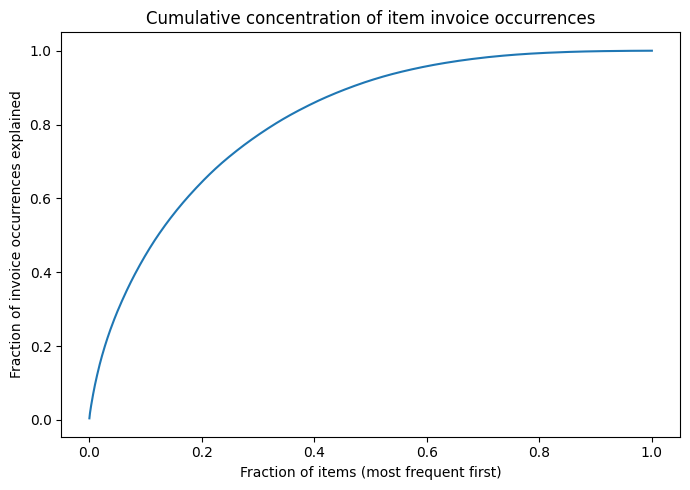

In [3]:
curve = rq1_res["cumulative_item_curve"]

plt.figure(figsize=(7, 5))
plt.plot(curve["cum_item_share"], curve["cum_occurrence_share"])
plt.title("Cumulative concentration of item invoice occurrences")
plt.xlabel("Fraction of items (most frequent first)")
plt.ylabel("Fraction of invoice occurrences explained")
plt.tight_layout()
plt.show()

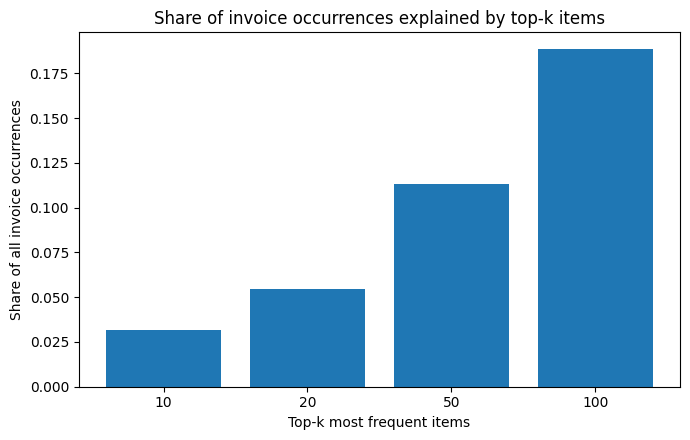

In [4]:
hc = rq1_res["head_concentration"]

plt.figure(figsize=(7, 4.5))
plt.bar(hc["top_k_items"].astype(str), hc["share_of_all_invoice_occurrences"])
plt.title("Share of invoice occurrences explained by top-k items")
plt.xlabel("Top-k most frequent items")
plt.ylabel("Share of all invoice occurrences")
plt.tight_layout()
plt.show()

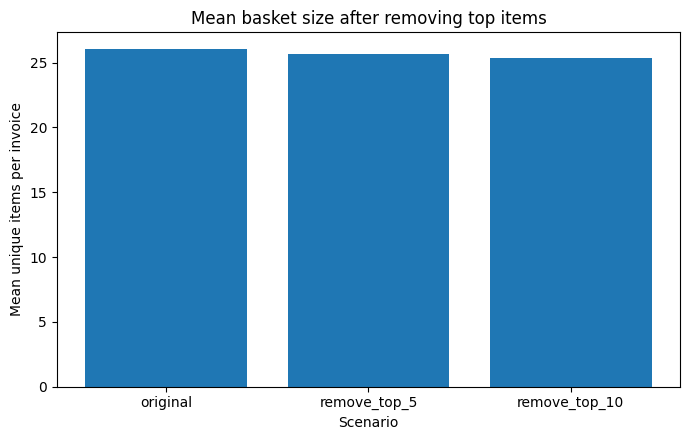

In [5]:
bs = rq1_res["basket_sensitivity"]

plt.figure(figsize=(7, 4.5))
plt.bar(bs["scenario"], bs["mean_basket_size"])
plt.title("Mean basket size after removing top items")
plt.xlabel("Scenario")
plt.ylabel("Mean unique items per invoice")
plt.tight_layout()
plt.show()

For additional EDA on RQ1, we measured how strongly the most popular items dominate basket activity and pair activity. We first ranked items by invoice-level support, then examined how much of all invoice occurrences came from the top 10, 20, 50, and 100 items. We also checked how often the strongest co-occurring pairs included at least one of these top items, and we tested how basket structure changed after removing a small set of the most frequent products. To support this, we created a top-items table, a head-concentration table, a pair-anchor table, a cumulative concentration plot, a top-k share bar chart, and a basket-sensitivity table and plot.

The additional EDA shows that popular items matter a lot, especially in the strongest pair relationships, but they do not fully dominate the whole dataset. The top items appear in many invoices, and the strongest co-occurring pairs are heavily anchored by them. For example, a large share of the top 100 and top 500 pairs includes at least one top item. At the same time, the head-concentration results and cumulative plot show that a large amount of basket activity is still spread across the long tail of less common items. Removing the top 5 or top 10 items only slightly reduces average basket size, which suggests that many baskets still contain a rich mix of other products. Overall, these results support the idea that popular items may hide smaller and more specific basket patterns, especially among the highest-support rules, which makes this research question both meaningful and well grounded.

### RQ2. Do products that are bought together in the same basket also tend to be bought in later transactions?

In the original EDA, the co-occurrence analysis showed strong item pairs within the same basket, but the temporal gap analysis suggests that customers also return over time in different patterns. This leads to a useful comparison: some products may be bought together in one invoice, while others may be bought in sequence across different purchases.
- Data mining task type: Association rule mining and sequential pattern mining
- Relevant algorithms: Apriori or FP-Growth for basket rules, PrefixSpan for sequences
- Evaluation criteria: Support, confidence, lift, sequential support, and interpretability

In [6]:
def rq2_basket_vs_sequence_eda(
    file_path: str,
    top_n_pairs: int = 20,
    top_n_transitions: int = 20,
    top_m_items_for_transitions: int = 500,
    max_items_per_invoice_for_transitions: int = 100,
):
    """
    Additional EDA for RQ2:
    Do products that are bought together in the same basket also tend to be bought in later transactions?

    What this function does
    - Loads the Online Retail dataset from an Excel file
    - Filters to purchase-only rows
    - Defines baskets as unique items per invoice
    - Creates one row per invoice with customer and timestamp
    - Measures sequence feasibility by counting repeat-purchase customers
    - Computes same-basket item-pair support
    - Computes cross-transaction item-to-item transition support from one invoice to the next
    - Compares top basket pairs with top sequential transitions

    Parameters
    ----------
    file_path : str
        Path to the Online Retail Excel file.
    top_n_pairs : int, default=20
        Number of top basket pairs to return.
    top_n_transitions : int, default=20
        Number of top sequential transitions to return.
    top_m_items_for_transitions : int, default=500
        Restrict transition analysis to top-M most frequent items for feasibility.
    max_items_per_invoice_for_transitions : int, default=100
        Ignore very large invoices when generating cross-invoice item transitions.

    Returns
    -------
    dict with:
    - df_purchase
    - invoice_item
    - invoice_meta
    - customer_invoice_counts
    - sequence_feasibility
    - pair_support_sorted
    - transition_support_sorted
    - pair_transition_overlap
    """
    # -----------------------------
    # 1) Load and clean
    # -----------------------------
    df = pd.read_excel(file_path)

    df["InvoiceNo"] = df["InvoiceNo"].astype(str)
    df["StockCode"] = df["StockCode"].astype(str)

    is_cancellation = df["InvoiceNo"].str.startswith("C", na=False)

    df_purchase = df.loc[~is_cancellation].copy()
    df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
    df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()
    df_purchase = df_purchase.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate"])
    df_purchase = df_purchase.loc[df_purchase["StockCode"].str.strip() != ""].copy()

    # -----------------------------
    # 2) Basket = unique items per invoice
    # -----------------------------
    invoice_item = (
        df_purchase[["InvoiceNo", "StockCode", "Description"]]
        .copy()
        .drop_duplicates(subset=["InvoiceNo", "StockCode"])
    )
    invoice_item["Description"] = invoice_item["Description"].astype(str).str.strip()

    # Invoice metadata
    meta_cols = ["InvoiceNo", "CustomerID", "InvoiceDate", "Country"]
    invoice_meta = (
        df_purchase[meta_cols]
        .drop_duplicates(subset=["InvoiceNo"])
        .copy()
    )
    invoice_meta["InvoiceDate"] = pd.to_datetime(invoice_meta["InvoiceDate"], errors="coerce")
    invoice_meta = invoice_meta.dropna(subset=["InvoiceDate", "CustomerID"])
    invoice_meta["CustomerID"] = invoice_meta["CustomerID"].astype(str)

    # Keep only invoices with known customer IDs for sequence work
    invoice_item_seq = invoice_item.merge(
        invoice_meta[["InvoiceNo", "CustomerID", "InvoiceDate", "Country"]],
        on="InvoiceNo",
        how="inner"
    )

    # -----------------------------
    # 3) Sequence feasibility
    # -----------------------------
    customer_invoice_counts = (
        invoice_meta.groupby("CustomerID")["InvoiceNo"]
        .nunique()
        .rename("n_invoices")
        .sort_values(ascending=False)
        .to_frame()
    )

    thresholds = [2, 3, 4, 5]
    sequence_feasibility = pd.DataFrame({
        "min_invoices_per_customer": thresholds,
        "n_customers": [
            int((customer_invoice_counts["n_invoices"] >= t).sum())
            for t in thresholds
        ],
        "share_of_customers": [
            float((customer_invoice_counts["n_invoices"] >= t).mean())
            for t in thresholds
        ],
    })

    # -----------------------------
    # 4) Same-basket pair support
    # -----------------------------
    basket_pairs_base = invoice_item[["InvoiceNo", "StockCode"]].copy()
    basket_pairs = basket_pairs_base.merge(
        basket_pairs_base,
        on="InvoiceNo",
        suffixes=("_a", "_b")
    )
    basket_pairs = basket_pairs.loc[
        basket_pairs["StockCode_a"] < basket_pairs["StockCode_b"],
        ["StockCode_a", "StockCode_b"]
    ]

    pair_support_sorted = (
        basket_pairs.value_counts()
        .rename("invoice_count")
        .reset_index()
        .sort_values("invoice_count", ascending=False)
        .reset_index(drop=True)
    )

    # -----------------------------
    # 5) Top items for transition restriction
    # -----------------------------
    item_support = (
        invoice_item.groupby("StockCode")["InvoiceNo"]
        .nunique()
        .rename("invoice_count")
        .sort_values(ascending=False)
        .to_frame()
    )
    top_item_set = set(item_support.head(top_m_items_for_transitions).index.astype(str))

    seq_base = invoice_item_seq.loc[
        invoice_item_seq["StockCode"].isin(top_item_set),
        ["InvoiceNo", "StockCode", "CustomerID", "InvoiceDate"]
    ].copy()

    # Invoice sizes for transition cap
    invoice_sizes = (
        seq_base.groupby("InvoiceNo")["StockCode"]
        .nunique()
        .rename("invoice_size")
        .reset_index()
    )
    seq_base = seq_base.merge(invoice_sizes, on="InvoiceNo", how="left")
    seq_base = seq_base.loc[seq_base["invoice_size"] <= max_items_per_invoice_for_transitions].copy()

    # -----------------------------
    # 6) Consecutive invoice transitions
    # -----------------------------
    invoice_order = (
        seq_base[["InvoiceNo", "CustomerID", "InvoiceDate"]]
        .drop_duplicates()
        .sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
        .copy()
    )
    invoice_order["next_invoice"] = invoice_order.groupby("CustomerID")["InvoiceNo"].shift(-1)
    invoice_order = invoice_order.dropna(subset=["next_invoice"]).copy()
    invoice_order["next_invoice"] = invoice_order["next_invoice"].astype(str)

    current_items = seq_base[["InvoiceNo", "StockCode"]].rename(
        columns={"InvoiceNo": "current_invoice", "StockCode": "item_a"}
    )
    next_items = seq_base[["InvoiceNo", "StockCode"]].rename(
        columns={"InvoiceNo": "next_invoice", "StockCode": "item_b"}
    )

    invoice_links = invoice_order.rename(columns={"InvoiceNo": "current_invoice"})[
        ["CustomerID", "current_invoice", "next_invoice"]
    ]

    transitions = (
        invoice_links
        .merge(current_items, on="current_invoice", how="inner")
        .merge(next_items, on="next_invoice", how="inner")
    )

    transition_support_sorted = (
        transitions.groupby(["item_a", "item_b"])
        .size()
        .rename("transition_count")
        .reset_index()
        .sort_values("transition_count", ascending=False)
        .reset_index(drop=True)
    )

    # -----------------------------
    # 7) Overlap between strong basket pairs and strong transitions
    # -----------------------------
    top_pairs_set = set(
        pair_support_sorted.head(top_n_pairs).apply(
            lambda r: tuple(sorted([r["StockCode_a"], r["StockCode_b"]])),
            axis=1
        )
    )

    top_transitions_set_unordered = set(
        transition_support_sorted.head(top_n_transitions).apply(
            lambda r: tuple(sorted([r["item_a"], r["item_b"]])),
            axis=1
        )
    )

    overlap_count = len(top_pairs_set & top_transitions_set_unordered)

    pair_transition_overlap = pd.DataFrame({
        "metric": [
            "top_n_pairs",
            "top_n_transitions",
            "unordered_overlap_count",
            "unordered_overlap_share_vs_pairs",
            "unordered_overlap_share_vs_transitions",
        ],
        "value": [
            top_n_pairs,
            top_n_transitions,
            overlap_count,
            overlap_count / top_n_pairs if top_n_pairs > 0 else np.nan,
            overlap_count / top_n_transitions if top_n_transitions > 0 else np.nan,
        ]
    })

    # Descriptions for readability
    desc_map = (
        invoice_item.dropna(subset=["Description"])
        .groupby("StockCode")["Description"]
        .agg(lambda x: x.value_counts().index[0])
    )

    top_pairs = pair_support_sorted.head(top_n_pairs).copy()
    top_pairs["desc_a"] = top_pairs["StockCode_a"].map(desc_map)
    top_pairs["desc_b"] = top_pairs["StockCode_b"].map(desc_map)

    top_transitions = transition_support_sorted.head(top_n_transitions).copy()
    top_transitions["desc_a"] = top_transitions["item_a"].map(desc_map)
    top_transitions["desc_b"] = top_transitions["item_b"].map(desc_map)

    return {
        "df_purchase": df_purchase,
        "invoice_item": invoice_item,
        "invoice_meta": invoice_meta,
        "customer_invoice_counts": customer_invoice_counts,
        "sequence_feasibility": sequence_feasibility,
        "pair_support_sorted": pair_support_sorted,
        "transition_support_sorted": transition_support_sorted,
        "pair_transition_overlap": pair_transition_overlap,
        "top_pairs": top_pairs,
        "top_transitions": top_transitions,
    }

In [7]:
file_path = "Online Retail.xlsx"

rq2_res = rq2_basket_vs_sequence_eda(file_path=file_path)

display(rq2_res["sequence_feasibility"])
display(rq2_res["pair_transition_overlap"])
display(rq2_res["top_pairs"])
display(rq2_res["top_transitions"])

,min_invoices_per_customer,n_customers,share_of_customers
0,2,2845,0.655832
1,3,2010,0.463347
2,4,1502,0.346243
3,5,1114,0.256800


,metric,value
0,top_n_pairs,20.0
1,top_n_transitions,20.0
2,unordered_overlap_count,4.0
3,unordered_overlap_share_vs_pairs,0.2
4,unordered_overlap_share_vs_transitions,0.2


,StockCode_a,StockCode_b,invoice_count,desc_a,desc_b
0,22386,85099B,825,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT
1,22697,22699,767,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER
2,21931,85099B,724,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT
3,22411,85099B,680,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT
4,20725,22383,655,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN
5,20725,20727,641,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.
6,22726,22727,640,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED
7,22697,22698,632,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER
8,20725,22384,606,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT
9,22698,22699,598,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER


,item_a,item_b,transition_count,desc_a,desc_b
0,POST,POST,690,POSTAGE,POSTAGE
1,85123A,85123A,609,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
2,85099B,85099B,442,JUMBO BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT
3,84879,84879,369,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT
4,22423,22423,366,REGENCY CAKESTAND 3 TIER,REGENCY CAKESTAND 3 TIER
5,47566,47566,348,PARTY BUNTING,PARTY BUNTING
6,20725,20725,344,LUNCH BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT
7,23203,23203,336,JUMBO BAG VINTAGE DOILY,JUMBO BAG VINTAGE DOILY
8,22197,22197,323,POPCORN HOLDER,POPCORN HOLDER
9,22383,22383,311,LUNCH BAG SUKI DESIGN,LUNCH BAG SUKI DESIGN


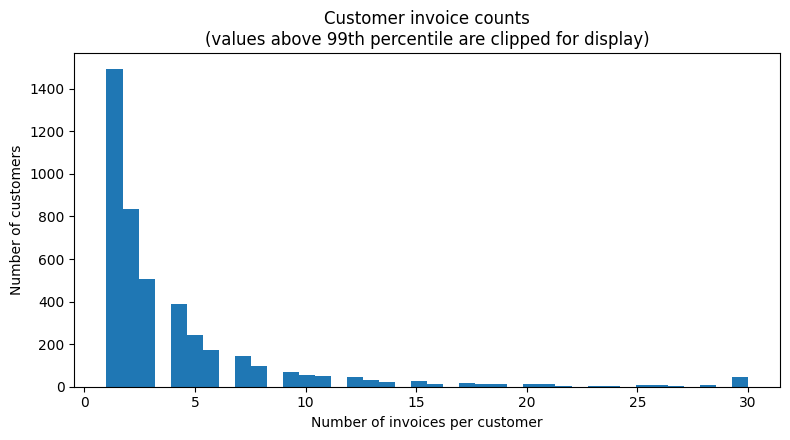

In [8]:
cust_counts = rq2_res["customer_invoice_counts"]["n_invoices"]

plt.figure(figsize=(8, 4.5))
plt.hist(cust_counts.clip(upper=cust_counts.quantile(0.99)), bins=40)
plt.title("Customer invoice counts\n(values above 99th percentile are clipped for display)")
plt.xlabel("Number of invoices per customer")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

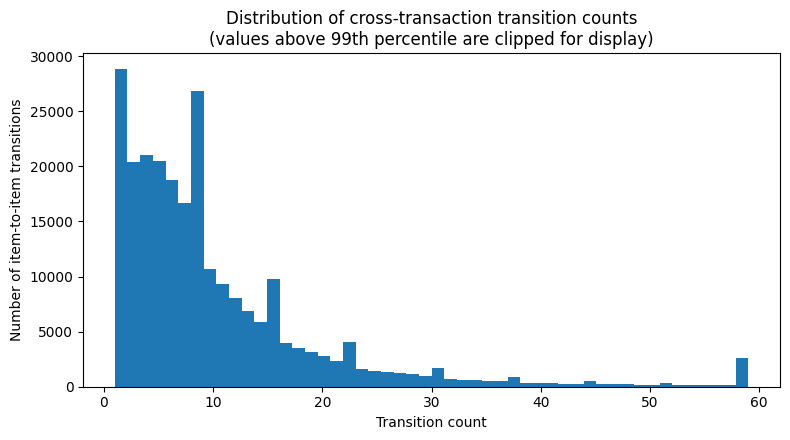

In [9]:
ts = rq2_res["transition_support_sorted"]["transition_count"]

plt.figure(figsize=(8, 4.5))
plt.hist(ts.clip(upper=ts.quantile(0.99)), bins=50)
plt.title("Distribution of cross-transaction transition counts\n(values above 99th percentile are clipped for display)")
plt.xlabel("Transition count")
plt.ylabel("Number of item-to-item transitions")
plt.tight_layout()
plt.show()

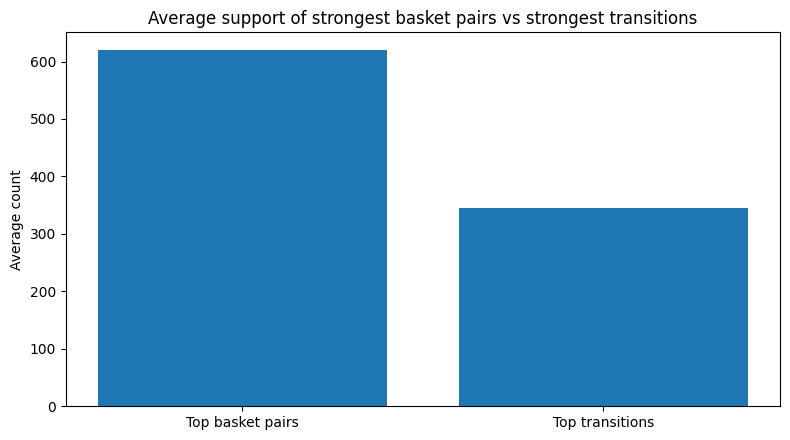

In [10]:
top_pairs = rq2_res["top_pairs"].copy()
top_transitions = rq2_res["top_transitions"].copy()

plt.figure(figsize=(8, 4.5))
plt.bar(["Top basket pairs", "Top transitions"], [
    top_pairs["invoice_count"].mean(),
    top_transitions["transition_count"].mean()
])
plt.title("Average support of strongest basket pairs vs strongest transitions")
plt.ylabel("Average count")
plt.tight_layout()
plt.show()

For additional EDA on RQ2, we checked whether sequential pattern mining is feasible and whether same-basket patterns look similar to cross-transaction patterns. We counted how many customers have at least 2, 3, 4, or 5 invoices, then compared two kinds of relationships: item pairs bought together in the same basket and item-to-item transitions from one invoice to the next for the same customer. To support this, we created a sequence-feasibility table, an overlap table, top basket-pair and top transition tables, and plots for customer invoice counts, transition-count distribution, and average support of top basket pairs versus top transitions.

The results show that RQ2 is both feasible and meaningful. Sequence mining is workable because many customers have repeat purchases, but repeat activity is uneven across customers. At the same time, the overlap between the top 20 basket pairs and the top 20 transitions is only 20%, which suggests that products bought together are often different from products bought again later. The top basket pairs are mostly matching or related items bought at the same time, while the top transitions include many repeated purchases of the same item and a smaller number of repeated product-family transitions. The plots also show that transition counts are long-tailed and that the strongest basket pairs have much higher support than the strongest transitions. Overall, this suggests that sequential patterns can reveal repeat-buying and follow-up relationships that unordered basket rules may miss.

### RQ3. Does shopping rhythm change the basket rules and sequential patterns we find?

The original EDA's temporal gap analysis showed that customers do not shop at the same pace. Some customers make repeat purchases quickly, while others return only after long gaps. This suggests that shopping rhythm may affect both same-basket patterns and time-ordered purchase sequences.
- Data mining task type: Association rule mining and sequential pattern mining by customer segment
- Relevant algorithms: Apriori or FP-Growth for basket rules, PrefixSpan for sequences
- Evaluation criteria: Support, confidence, lift, sequential support, pattern stability, and interpretability

In [11]:
def rq3_shopping_rhythm_eda(
    file_path: str,
    time_col: str = "InvoiceDate",
    customer_col: str = "CustomerID",
    invoice_col: str = "InvoiceNo",
    stock_col: str = "StockCode",
    country_col: str = "Country",
):
    """
    Additional EDA for RQ3:
    Does shopping rhythm change the basket rules and sequential patterns we find?

    What this function does
    - Loads the Online Retail dataset
    - Filters to purchase-only rows
    - Builds one row per invoice with customer and time
    - Computes transaction gaps in days for each customer
    - Computes each customer's median transaction gap
    - Segments customers into fast / medium / slow shoppers using terciles
    - Summarizes invoice counts, basket sizes, and sequence feasibility by segment

    Parameters
    ----------
    file_path : str
        Path to the Online Retail Excel file.
    time_col, customer_col, invoice_col, stock_col, country_col : str
        Relevant column names.

    Returns
    -------
    dict with:
    - df_purchase
    - invoice_item
    - invoice_meta
    - gaps
    - customer_gap_summary
    - segment_cutoffs
    - segment_summary
    - sequence_feasibility_by_segment
    - basket_summary_by_segment
    """
    # -----------------------------
    # 1) Load and clean
    # -----------------------------
    df = pd.read_excel(file_path)

    df[invoice_col] = df[invoice_col].astype(str)
    df[stock_col] = df[stock_col].astype(str)

    is_cancellation = df[invoice_col].str.startswith("C", na=False)

    df_purchase = df.loc[~is_cancellation].copy()
    df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
    df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()
    df_purchase = df_purchase.dropna(subset=[invoice_col, stock_col, time_col])
    df_purchase = df_purchase.loc[df_purchase[stock_col].str.strip() != ""].copy()

    # -----------------------------
    # 2) Invoice-item and invoice metadata
    # -----------------------------
    invoice_item = (
        df_purchase[[invoice_col, stock_col]]
        .drop_duplicates()
        .copy()
    )

    meta_cols = [invoice_col, customer_col, time_col]
    if country_col in df_purchase.columns:
        meta_cols.append(country_col)

    invoice_meta = (
        df_purchase[meta_cols]
        .drop_duplicates(subset=[invoice_col])
        .copy()
    )

    invoice_meta[time_col] = pd.to_datetime(invoice_meta[time_col], errors="coerce")
    invoice_meta = invoice_meta.dropna(subset=[time_col, customer_col]).copy()
    invoice_meta[customer_col] = invoice_meta[customer_col].astype(str)

    # Keep only invoices with known customer ids
    invoice_item = invoice_item.merge(
        invoice_meta[[invoice_col, customer_col, time_col] + ([country_col] if country_col in invoice_meta.columns else [])],
        on=invoice_col,
        how="inner"
    )

    # -----------------------------
    # 3) Compute customer transaction gaps
    # -----------------------------
    invoice_order = (
        invoice_meta.sort_values([customer_col, time_col, invoice_col])
        .copy()
    )

    invoice_order["prev_time"] = invoice_order.groupby(customer_col)[time_col].shift(1)
    invoice_order["gap_days"] = (
        (invoice_order[time_col] - invoice_order["prev_time"]).dt.total_seconds() / (24 * 3600)
    )

    gaps = invoice_order.dropna(subset=["gap_days"]).copy()

    # -----------------------------
    # 4) Customer-level gap summary
    # -----------------------------
    customer_gap_summary = (
        gaps.groupby(customer_col)["gap_days"]
        .agg(
            n_gaps="size",
            median_gap_days="median",
            mean_gap_days="mean"
        )
        .reset_index()
    )

    # Add invoice counts per customer
    customer_invoice_counts = (
        invoice_meta.groupby(customer_col)[invoice_col]
        .nunique()
        .rename("n_invoices")
        .reset_index()
    )

    customer_gap_summary = customer_gap_summary.merge(
        customer_invoice_counts,
        on=customer_col,
        how="left"
    )

    # -----------------------------
    # 5) Segment customers by median gap
    # -----------------------------
    q1 = customer_gap_summary["median_gap_days"].quantile(1/3)
    q2 = customer_gap_summary["median_gap_days"].quantile(2/3)

    def assign_segment(x):
        if x <= q1:
            return "fast"
        elif x <= q2:
            return "medium"
        else:
            return "slow"

    customer_gap_summary["shopping_rhythm"] = customer_gap_summary["median_gap_days"].apply(assign_segment)

    segment_cutoffs = pd.DataFrame({
        "cutoff": ["fast_upper", "medium_upper"],
        "gap_days": [q1, q2]
    })

    # -----------------------------
    # 6) Attach segment back to invoices
    # -----------------------------
    invoice_meta_seg = invoice_meta.merge(
        customer_gap_summary[[customer_col, "shopping_rhythm", "median_gap_days", "n_invoices"]],
        on=customer_col,
        how="inner"
    )

    invoice_item_seg = invoice_item.merge(
        invoice_meta_seg[[invoice_col, customer_col, "shopping_rhythm"]],
        on=[invoice_col, customer_col],
        how="inner"
    )

    # -----------------------------
    # 7) Segment summary
    # -----------------------------
    segment_summary = (
        customer_gap_summary.groupby("shopping_rhythm")
        .agg(
            n_customers=(customer_col, "nunique"),
            mean_median_gap_days=("median_gap_days", "mean"),
            median_median_gap_days=("median_gap_days", "median"),
            mean_n_invoices=("n_invoices", "mean"),
            median_n_invoices=("n_invoices", "median"),
        )
        .reset_index()
    )

    # -----------------------------
    # 8) Sequence feasibility by segment
    # -----------------------------
    thresholds = [2, 3, 4, 5]
    seq_rows = []

    for seg, sub in customer_gap_summary.groupby("shopping_rhythm"):
        n_customers = sub[customer_col].nunique()
        for t in thresholds:
            cnt = int((sub["n_invoices"] >= t).sum())
            seq_rows.append({
                "shopping_rhythm": seg,
                "min_invoices_per_customer": t,
                "n_customers": cnt,
                "share_of_segment_customers": cnt / n_customers if n_customers > 0 else np.nan,
            })

    sequence_feasibility_by_segment = pd.DataFrame(seq_rows)

    # -----------------------------
    # 9) Basket summary by segment
    # -----------------------------
    basket_sizes = (
        invoice_item_seg.groupby([invoice_col, "shopping_rhythm"])[stock_col]
        .nunique()
        .rename("basket_size")
        .reset_index()
    )

    basket_summary_by_segment = (
        basket_sizes.groupby("shopping_rhythm")["basket_size"]
        .agg(
            n_invoices="size",
            mean_basket_size="mean",
            median_basket_size="median",
            p90_basket_size=lambda x: x.quantile(0.9),
        )
        .reset_index()
    )

    return {
        "df_purchase": df_purchase,
        "invoice_item": invoice_item,
        "invoice_meta": invoice_meta,
        "gaps": gaps,
        "customer_gap_summary": customer_gap_summary,
        "segment_cutoffs": segment_cutoffs,
        "segment_summary": segment_summary,
        "sequence_feasibility_by_segment": sequence_feasibility_by_segment,
        "basket_summary_by_segment": basket_summary_by_segment,
    }

In [12]:
file_path = "Online Retail.xlsx"
rq3_res = rq3_shopping_rhythm_eda(file_path=file_path)

display(rq3_res["segment_cutoffs"])
display(rq3_res["segment_summary"])
display(rq3_res["sequence_feasibility_by_segment"])
display(rq3_res["basket_summary_by_segment"])

,cutoff,gap_days
0,fast_upper,31.010417
1,medium_upper,70.004167


,shopping_rhythm,n_customers,mean_median_gap_days,median_median_gap_days,mean_n_invoices,median_n_invoices
0,fast,948,16.191064,16.949653,10.176160,6.0
1,medium,949,48.002058,46.579861,5.014752,5.0
2,slow,948,141.774621,119.090972,2.777426,3.0


,shopping_rhythm,min_invoices_per_customer,n_customers,share_of_segment_customers
0,fast,2,948,1.000000
1,fast,3,744,0.784810
2,fast,4,660,0.696203
3,fast,5,569,0.600211
4,medium,2,949,1.000000
5,medium,3,789,0.831401
6,medium,4,653,0.688093
7,medium,5,488,0.514226
8,slow,2,948,1.000000
9,slow,3,477,0.503165


,shopping_rhythm,n_invoices,mean_basket_size,median_basket_size,p90_basket_size
0,fast,9647,19.937079,14.0,45.0
1,medium,4759,21.596344,16.0,46.0
2,slow,2633,22.927079,16.0,50.0


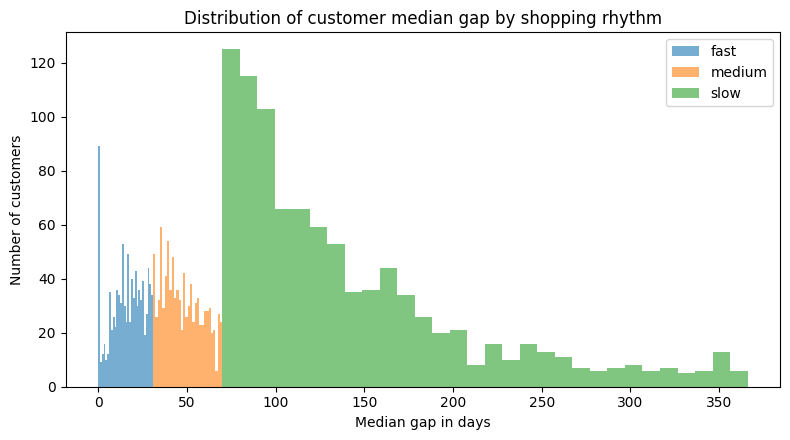

In [13]:
cust = rq3_res["customer_gap_summary"]

plt.figure(figsize=(8, 4.5))
for seg in ["fast", "medium", "slow"]:
    vals = cust.loc[cust["shopping_rhythm"] == seg, "median_gap_days"]
    plt.hist(vals, bins=30, alpha=0.6, label=seg)

plt.title("Distribution of customer median gap by shopping rhythm")
plt.xlabel("Median gap in days")
plt.ylabel("Number of customers")
plt.legend()
plt.tight_layout()
plt.show()

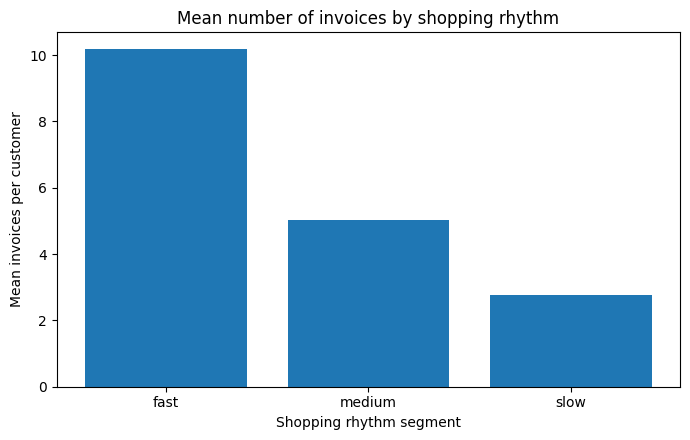

In [14]:
seg = rq3_res["segment_summary"]

plt.figure(figsize=(7, 4.5))
plt.bar(seg["shopping_rhythm"], seg["mean_n_invoices"])
plt.title("Mean number of invoices by shopping rhythm")
plt.xlabel("Shopping rhythm segment")
plt.ylabel("Mean invoices per customer")
plt.tight_layout()
plt.show()

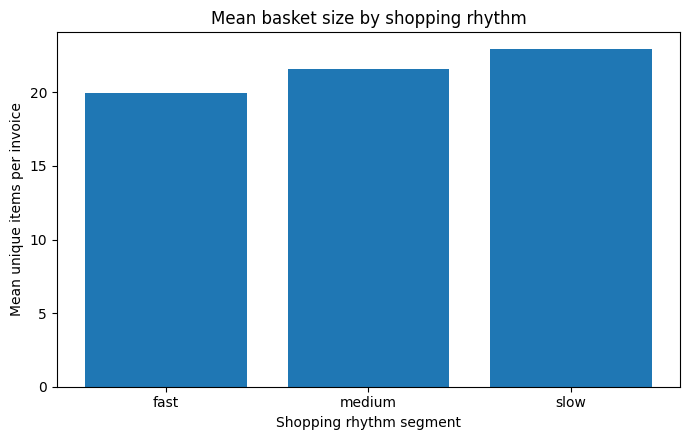

In [15]:
bs = rq3_res["basket_summary_by_segment"]

plt.figure(figsize=(7, 4.5))
plt.bar(bs["shopping_rhythm"], bs["mean_basket_size"])
plt.title("Mean basket size by shopping rhythm")
plt.xlabel("Shopping rhythm segment")
plt.ylabel("Mean unique items per invoice")
plt.tight_layout()
plt.show()

For additional EDA on RQ3, we grouped customers by shopping rhythm using their median gap between consecutive transactions. We defined three segments based on terciles: fast shoppers with median gaps up to about 31 days, medium shoppers with median gaps between about 31 and 70 days, and slow shoppers with median gaps above about 70 days. We then summarized each segment by number of customers, typical gap length, average number of invoices per customer, sequence feasibility at different minimum invoice thresholds, and basket size. To support this, we created cutoff and segment summary tables, a sequence-feasibility-by-segment table, a basket summary table, and three plots showing the gap distribution, mean invoices per customer, and mean basket size by segment.

The results show that shopping rhythm is strongly related to both repeat-purchase behavior and basket structure. Fast shoppers have many more invoices per customer, which makes sequence mining much more feasible for them, while slow shoppers have far fewer repeat transactions. At the same time, slow shoppers tend to place slightly larger baskets. The plots show these differences clearly. The three rhythm groups are well separated by median gap. Fast shoppers buy more often, while slow shoppers buy less often but in somewhat larger baskets. Overall, this suggests that shopping rhythm is likely to change both basket rules and sequential patterns, so customer segmentation should reveal more specific patterns than analyzing all customers together.

## 3. RQ-to-Method Mapping Table

| RQ | Course Methods | External Methods |
|---|---|---|
| **RQ1. Do popular items hide more specific but useful basket patterns?** | Frequent itemsets, association rules | None |
| **RQ2. Do products bought together in the same basket also tend to be bought in later transactions?** | Association rules | Sequential pattern mining |
| **RQ3. Does shopping rhythm change the basket rules and sequential patterns we find?** | Association rules by segment | Sequential pattern mining by segment |

## 4. Motivation and Feasibility

- Motivation: The EDA showed a long-tail pattern in item frequency, strong concentration in a small set of co-occurring pairs, and clear variation in transaction gaps across customers. These patterns suggest that both basket structure and time order are important in this dataset.
- Non-triviality: Frequent itemsets and association rules can find products bought together in the same basket, but they ignore purchase order across time. Sequential pattern mining adds this missing structure and may reveal repeat-buying or follow-up relationships that basket rules miss.
- Feasibility: The dataset is large enough to contain meaningful basket and sequence patterns, but still manageable on a single machine with careful filtering. The additional EDA also showed that many customers have repeat purchases, and that the fast, medium, and slow shopping-rhythm segments are all large enough for comparison.
- Risks: The main risks are computational cost, sensitivity to support thresholds, and dominance by very popular items. If support is too high, we may only find obvious patterns. If it is too low, we may get too many weak or noisy patterns.

## 5. Methodological Planning

- Course algorithms: Apriori and FP-Growth for frequent itemset mining and then generate association rules from the frequent itemsets.
- External algorithms: PrefixSpan for sequential pattern mining on customer purchase sequences ordered by transaction time.
- Evaluation:
  - Basket patterns: support, confidence, lift, interpretability and pattern diversity.
  - Sequential patterns: sequential support, pattern length, and whether the patterns reveal meaningful repeat-buying or follow-up behavior.
- Baselines: High-support-only mining
- Main implementation choices:
  - Use purchase-only data.
  - Remove cancellations and returns.
  - Deduplicate items within each invoice.
  - Tune support thresholds carefully to balance pattern quality and computational cost.

## 6. Initial Methods Feasibility

In [17]:
import time
from itertools import combinations, product

# =========================================================
# 1) Load and prepare purchase-only data
# =========================================================
file_path = "Online Retail.xlsx"

df = pd.read_excel(file_path)

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

is_cancellation = df["InvoiceNo"].str.startswith("C", na=False)

df_purchase = df.loc[~is_cancellation].copy()
df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()
df_purchase = df_purchase.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate"])
df_purchase = df_purchase.loc[df_purchase["StockCode"].str.strip() != ""].copy()

# Basket data: one invoice = one basket of unique items
invoice_item = df_purchase[["InvoiceNo", "StockCode"]].drop_duplicates().copy()
baskets = invoice_item.groupby("InvoiceNo")["StockCode"].apply(list)
n_baskets = len(baskets)

# Top items for small feasibility runs
item_support = (
    invoice_item.groupby("StockCode")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)
top_items_200 = set(item_support.head(200).index)
baskets_top = baskets.apply(lambda xs: sorted([x for x in xs if x in top_items_200]))
baskets_top = baskets_top[baskets_top.apply(len) > 0]

print(f"Purchase-only baskets: {n_baskets:,}")
print(f"Trial baskets with top-200 items: {len(baskets_top):,}")

Purchase-only baskets: 19,960
Trial baskets with top-200 items: 17,468


In [18]:
# =========================================================
# 2) Small Apriori-style feasibility trial
# =========================================================
def trial_apriori_pairs_triples(baskets_series, min_support_frac=0.01, max_k=3):
    """
    Small feasibility run.
    Counts frequent 1-itemsets, 2-itemsets, and 3-itemsets among filtered baskets.
    This is only for checking runtime and output size.
    """
    start = time.perf_counter()
    n = len(baskets_series)
    min_count = int(np.ceil(min_support_frac * n))

    # 1-itemsets
    item_counts = {}
    for basket in baskets_series:
        for item in basket:
            item_counts[item] = item_counts.get(item, 0) + 1

    L1 = {tuple([k]): v for k, v in item_counts.items() if v >= min_count}
    results = [{"k": 1, "itemset": k, "support_count": v, "support": v / n} for k, v in L1.items()]

    frequent_items = sorted([k[0] for k in L1.keys()])
    fset = set(frequent_items)

    # 2-itemsets
    L2 = {}
    if max_k >= 2:
        pair_counts = {}
        for basket in baskets_series:
            b = sorted([x for x in basket if x in fset])
            for pair in combinations(b, 2):
                pair_counts[pair] = pair_counts.get(pair, 0) + 1

        L2 = {k: v for k, v in pair_counts.items() if v >= min_count}
        results.extend(
            [{"k": 2, "itemset": k, "support_count": v, "support": v / n} for k, v in L2.items()]
        )

    # 3-itemsets
    L3 = {}
    if max_k >= 3 and L2:
        pair_set = set(L2.keys())
        triple_counts = {}
        for basket in baskets_series:
            b = sorted([x for x in basket if x in fset])
            for triple in combinations(b, 3):
                if all(tuple(sorted(p)) in pair_set for p in combinations(triple, 2)):
                    triple_counts[triple] = triple_counts.get(triple, 0) + 1

        L3 = {k: v for k, v in triple_counts.items() if v >= min_count}
        results.extend(
            [{"k": 3, "itemset": k, "support_count": v, "support": v / n} for k, v in L3.items()]
        )

    elapsed = time.perf_counter() - start

    summary = pd.DataFrame({
        "min_support": [min_support_frac],
        "n_baskets": [n],
        "min_support_count": [min_count],
        "n_freq_1_itemsets": [len(L1)],
        "n_freq_2_itemsets": [len(L2)],
        "n_freq_3_itemsets": [len(L3)],
        "runtime_sec": [elapsed],
    })

    results_df = pd.DataFrame(results).sort_values(
        ["k", "support_count"], ascending=[True, False]
    ).reset_index(drop=True)

    return summary, results_df


apriori_summaries = []
apriori_results = {}

for s in [0.05, 0.02, 0.01]:
    summary, result = trial_apriori_pairs_triples(
        baskets_series=baskets_top,
        min_support_frac=s,
        max_k=3,
    )
    apriori_summaries.append(summary)
    apriori_results[s] = result

apriori_summary = pd.concat(apriori_summaries, ignore_index=True)

print("\nApriori-style feasibility summary")
display(apriori_summary)

print("\nTop itemsets at support 0.02")
display(apriori_results[0.02].head(20))


Apriori-style feasibility summary


,min_support,n_baskets,min_support_count,n_freq_1_itemsets,n_freq_2_itemsets,n_freq_3_itemsets,runtime_sec
0,0.05,17468,874,54,0,0,0.081869
1,0.02,17468,350,200,138,7,22.323142
2,0.01,17468,175,200,1208,477,22.646263



Top itemsets at support 0.02


,k,itemset,support_count,support
0,1,"(85123A,)",2198,0.125830
1,1,"(85099B,)",2089,0.119590
2,1,"(22423,)",1988,0.113808
3,1,"(47566,)",1685,0.096462
4,1,"(20725,)",1565,0.089592
5,1,"(84879,)",1455,0.083295
6,1,"(22197,)",1392,0.079689
7,1,"(22720,)",1385,0.079288
8,1,"(21212,)",1320,0.075567
9,1,"(22383,)",1284,0.073506


In [25]:
# =========================================================
# 3) Simple FP-Growth feasibility proxy
# =========================================================
# We do not implement full FP-Growth here.
# Instead, we use the same filtered baskets and compare runtime expectations:
# if 1/2/3-itemset trial runs are manageable, FP-Growth should also be feasible
# and often faster than Apriori on the same support settings.

fp_proxy = apriori_summary.copy()
print("\nFP-Growth feasibility proxy")
display(fp_proxy)


FP-Growth feasibility proxy


,min_support,n_baskets,min_support_count,n_freq_1_itemsets,n_freq_2_itemsets,n_freq_3_itemsets,runtime_sec
0,0.05,17468,874,54,0,0,0.081869
1,0.02,17468,350,200,138,7,22.323142
2,0.01,17468,175,200,1208,477,22.646263


In [20]:
# =========================================================
# 4) Build customer sequences for PrefixSpan-style feasibility
# =========================================================
invoice_meta = (
    df_purchase[["InvoiceNo", "CustomerID", "InvoiceDate"]]
    .drop_duplicates(subset=["InvoiceNo"])
    .copy()
)
invoice_meta["InvoiceDate"] = pd.to_datetime(invoice_meta["InvoiceDate"], errors="coerce")
invoice_meta = invoice_meta.dropna(subset=["CustomerID", "InvoiceDate"]).copy()
invoice_meta["CustomerID"] = invoice_meta["CustomerID"].astype(str)

invoice_items_seq = (
    invoice_item.merge(invoice_meta, on="InvoiceNo", how="inner")
)

# Restrict to top 100 items for small sequence trial
top_items_100 = set(item_support.head(100).index)
invoice_items_seq = invoice_items_seq.loc[invoice_items_seq["StockCode"].isin(top_items_100)].copy()

invoice_baskets_seq = (
    invoice_items_seq.groupby(["CustomerID", "InvoiceDate", "InvoiceNo"])["StockCode"]
    .apply(lambda s: sorted(set(s)))
    .reset_index()
    .sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"])
)

customer_sequences = (
    invoice_baskets_seq.groupby("CustomerID")["StockCode"]
    .apply(list)
)

# Keep only customers with at least 2 baskets
customer_sequences = customer_sequences[customer_sequences.apply(len) >= 2]

sequence_feasibility = pd.DataFrame({
    "metric": [
        "n_customers_with_sequences",
        "mean_sequence_length",
        "median_sequence_length",
        "max_sequence_length",
    ],
    "value": [
        len(customer_sequences),
        customer_sequences.apply(len).mean(),
        customer_sequences.apply(len).median(),
        customer_sequences.apply(len).max(),
    ],
})

print("\nSequence feasibility summary")
display(sequence_feasibility)


Sequence feasibility summary


,metric,value
0,n_customers_with_sequences,2457.000000
1,mean_sequence_length,5.531543
2,median_sequence_length,4.000000
3,max_sequence_length,173.000000


In [24]:
# =========================================================
# 5) Small PrefixSpan-style trial
# =========================================================
# We do not implement full PrefixSpan here.
# For feasibility, we check whether the sequence format is sensible and whether
# short sequential patterns are interpretable by counting:
# - repeated single-item sequences across consecutive baskets
# - cross-basket item -> item transitions

def trial_sequential_transitions(customer_sequences, top_n=20):
    single_repeat_counts = {}
    transition_counts = {}

    for seq in customer_sequences:
        for i in range(len(seq) - 1):
            a_items = seq[i]
            b_items = seq[i + 1]

            # repeated item in consecutive baskets
            for item in set(a_items).intersection(set(b_items)):
                single_repeat_counts[(item, item)] = single_repeat_counts.get((item, item), 0) + 1

            # item-to-item transitions
            for a, b in product(set(a_items), set(b_items)):
                transition_counts[(a, b)] = transition_counts.get((a, b), 0) + 1

    repeat_df = (
        pd.DataFrame(
            [{"item_a": k[0], "item_b": k[1], "count": v} for k, v in single_repeat_counts.items()]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    trans_df = (
        pd.DataFrame(
            [{"item_a": k[0], "item_b": k[1], "count": v} for k, v in transition_counts.items()]
        )
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )

    return repeat_df.head(top_n), trans_df.head(top_n), trans_df


repeat_top, transitions_top, transitions_all = trial_sequential_transitions(customer_sequences, top_n=20)

# Make explicit copies before adding columns
repeat_top = repeat_top.copy()
transitions_top = transitions_top.copy()

# Add descriptions for readability
desc_map = (
    df_purchase[["StockCode", "Description"]]
    .dropna()
    .assign(Description=lambda x: x["Description"].astype(str).str.strip())
    .drop_duplicates()
    .groupby("StockCode")["Description"]
    .agg(lambda x: x.value_counts().index[0])
)

repeat_top.loc[:, "desc_a"] = repeat_top["item_a"].map(desc_map)
repeat_top.loc[:, "desc_b"] = repeat_top["item_b"].map(desc_map)

transitions_top.loc[:, "desc_a"] = transitions_top["item_a"].map(desc_map)
transitions_top.loc[:, "desc_b"] = transitions_top["item_b"].map(desc_map)

print("\nTop repeated-item consecutive-basket patterns")
display(repeat_top)

print("\nTop item-to-item transitions across consecutive baskets")
display(transitions_top)


Top repeated-item consecutive-basket patterns


,item_a,item_b,count,desc_a,desc_b
0,POST,POST,709,POSTAGE,POSTAGE
1,85123A,85123A,658,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
2,85099B,85099B,483,JUMBO BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT
3,22423,22423,407,REGENCY CAKESTAND 3 TIER,REGENCY CAKESTAND 3 TIER
4,84879,84879,402,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT
5,20725,20725,373,LUNCH BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT
6,47566,47566,369,PARTY BUNTING,PARTY BUNTING
7,22197,22197,369,SMALL POPCORN HOLDER,SMALL POPCORN HOLDER
8,23203,23203,361,JUMBO BAG DOILEY PATTERNS,JUMBO BAG DOILEY PATTERNS
9,22383,22383,332,LUNCH BAG SUKI DESIGN,LUNCH BAG SUKI DESIGN



Top item-to-item transitions across consecutive baskets


,item_a,item_b,count,desc_a,desc_b
0,POST,POST,709,POSTAGE,POSTAGE
1,85123A,85123A,658,WHITE HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER
2,85099B,85099B,483,JUMBO BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT
3,22423,22423,407,REGENCY CAKESTAND 3 TIER,REGENCY CAKESTAND 3 TIER
4,84879,84879,402,ASSORTED COLOUR BIRD ORNAMENT,ASSORTED COLOUR BIRD ORNAMENT
5,20725,20725,373,LUNCH BAG RED RETROSPOT,LUNCH BAG RED RETROSPOT
6,22197,22197,369,SMALL POPCORN HOLDER,SMALL POPCORN HOLDER
7,47566,47566,369,PARTY BUNTING,PARTY BUNTING
8,23203,23203,361,JUMBO BAG DOILEY PATTERNS,JUMBO BAG DOILEY PATTERNS
9,85099B,23203,334,JUMBO BAG RED RETROSPOT,JUMBO BAG DOILEY PATTERNS


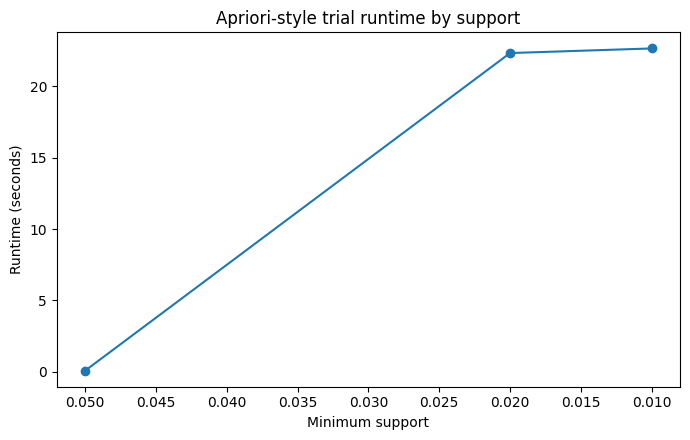

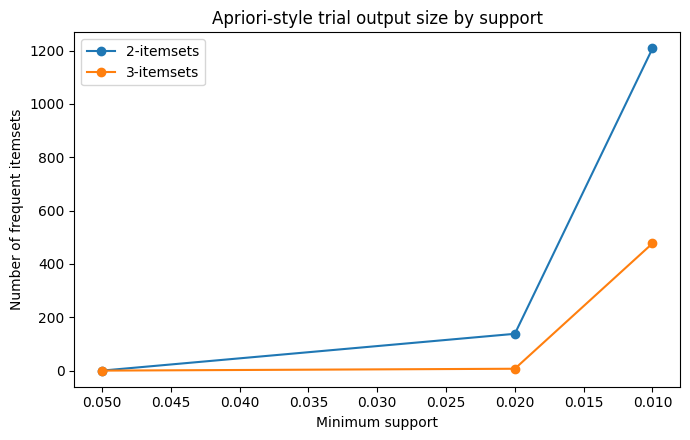

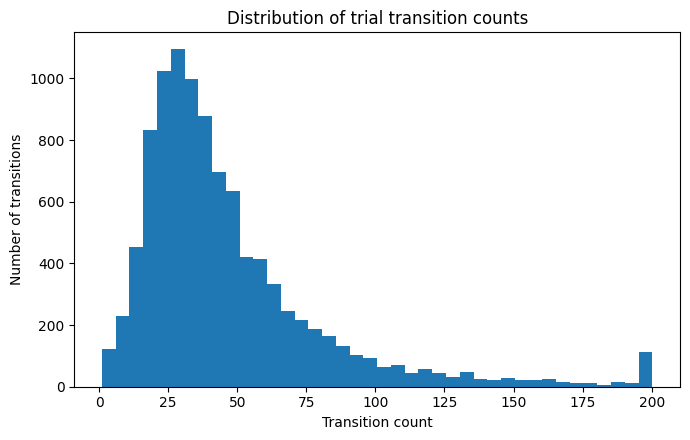

In [22]:
# =========================================================
# 6) Small plots for feasibility
# =========================================================
plt.figure(figsize=(7, 4.5))
plt.plot(apriori_summary["min_support"], apriori_summary["runtime_sec"], marker="o")
plt.gca().invert_xaxis()
plt.title("Apriori-style trial runtime by support")
plt.xlabel("Minimum support")
plt.ylabel("Runtime (seconds)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(apriori_summary["min_support"], apriori_summary["n_freq_2_itemsets"], marker="o", label="2-itemsets")
plt.plot(apriori_summary["min_support"], apriori_summary["n_freq_3_itemsets"], marker="o", label="3-itemsets")
plt.gca().invert_xaxis()
plt.title("Apriori-style trial output size by support")
plt.xlabel("Minimum support")
plt.ylabel("Number of frequent itemsets")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4.5))
plt.hist(transitions_all["count"].clip(upper=transitions_all["count"].quantile(0.99)), bins=40)
plt.title("Distribution of trial transition counts")
plt.xlabel("Transition count")
plt.ylabel("Number of transitions")
plt.tight_layout()
plt.show()

To check feasibility, we ran small trial experiments for both basket mining and sequence mining. For basket mining, we used purchase-only baskets restricted to the top 200 items and tested Apriori-style runs at support levels of 0.05, 0.02, and 0.01 to see how runtime and output size changed. This gave us a practical preview of whether Apriori would remain manageable as support decreased, and whether FP-Growth would likely be needed at lower support. For sequence mining, we built customer purchase sequences ordered by invoice time and ran a small transition-based trial to confirm that the sequence format was correct and that a PrefixSpan-style analysis would produce meaningful and interpretable patterns.

The trial results suggest that Apriori, FP-Growth, and PrefixSpan are all feasible, but they have different practical limits. Apriori is feasible at moderate support levels, but the number of frequent itemsets grows quickly as support drops, so it may become inefficient or produce too many patterns at very low support. FP-Growth should also be feasible on this dataset and is likely a better choice when support is lower, because it is designed to handle larger pattern spaces more efficiently than Apriori. PrefixSpan also looks feasible because there are 2457 customers with usable purchase sequences and the average sequence length is about 5.5 invoices. The top transition patterns are also easy to interpret. They include repeated purchases of the same item and transitions between related products in the same product family. Overall, the feasibility checks suggest that we need to choose the support threshold carefully for either Apriori or FP-Growth. For sequence mining, we should apply it to filtered sequences or customer segments to keep it manageable.

## Collaboration Declaration

On my honor, I declare the following resources:
1. Web Sources:
- https://archive.ics.uci.edu/dataset/352/online+retail: Online Retail Dataset

2. AI Tools:
- ChatGPT:
  - Research Question Definition: I provided the initial EDA to it to ask it to suggest some interesting research questions. I picked 3 among them. Then, for each question, I asked it to suggest some additional EDA that can be performed to make the question more grounded. Finally, I asked it to generate code to perform the EDA it suggested.
  - Motivation and Feasibility: I asked it to suggest some risks for this project.
  - Initial Methods Feasibility: I asked it to suggest some methods to verify that using Apropri, FP-Growth, and PrefixSpan is feasible for this dataset. Then I picked the methods that sound reasonable to me and asked it to generate code using these methods.